# ECG Signal Preprocessing Pipeline for Time-Series Forecasting

Based on the findings from "Pre-Processing techniques and artificial intelligence algorithms for electrocardiogram (ECG) signals analysis: A comprehensive review", this notebook implements a robust preprocessing pipeline for chaotic ECG time-series data. 

The pipeline is specifically designed to prepare the MIT-BIH Arrhythmia database (sampled at 360 Hz, 2-channels) for Deep Learning forecasting models (such as LSTM or Reservoir Computing). It emphasizes minimal structural distortion to preserve the non-linear chaotic dynamics (e.g., the QRS complex) using techniques explicitly highlighted in the paper:
1. Baseline wander removal via Median Filtering.
2. Signal denoising via Wavelet Transformation.
3. Channel-wise scaling for neural network stability.
4. Data enhancement via window-based slicing for forecasting.

In [3]:
import numpy as np
import wfdb
import pywt
from scipy.signal import medfilt
from sklearn.preprocessing import MinMaxScaler

# Define configuration based on MIT-BIH specifications mentioned in the paper
SAMPLING_RATE = 360

## Step 1: Data Acquisition
The paper identifies the MIT-BIH database as a major, highly explored dataset consisting of long Holter recordings. Here, we load the raw signal data. We extract the 2-channel continuous time-series data without relying on the pathological annotations, as our objective is self-supervised signal forecasting.

In [4]:
def load_mit_bih_record(record_name, sample_path='mitdb/'):
    # Fetching a small segment (e.g., first 650,000 samples) of record '100'
    record = wfdb.rdrecord(record_name, pn_dir='mitdb', sampto=650000)
    signals = record.p_signal
    return signals

# Load record 100
raw_signals = load_mit_bih_record('100')
print(f"Raw signal shape: {raw_signals.shape} (Samples, Channels)")

Raw signal shape: (650000, 2) (Samples, Channels)


## Step 2: Baseline Wander Removal
The paper notes that wearable and Holter devices capture low-frequency noises like baseline drift due to patient movement and respiration. As referenced in the paper's QRS detection section, applying a median filter is an optimal approach to remove baseline drift. It acts as a non-linear filter that centers the signal without introducing phase shifts or distorting the high-frequency R-peaks.

In [5]:
def remove_baseline_wander(signal_channel, fs=SAMPLING_RATE):
    """
    Removes baseline wander using two consecutive median filters.
    Window sizes are typically 0.2s and 0.6s to filter out breathing artifacts.
    """
    # Calculate window sizes (must be odd integers)
    win1 = int(0.2 * fs)
    win1 = win1 if win1 % 2 != 0 else win1 + 1
    
    win2 = int(0.6 * fs)
    win2 = win2 if win2 % 2 != 0 else win2 + 1
    
    # First median filter removes QRS complexes and P/T waves
    baseline_approx_1 = medfilt(signal_channel, kernel_size=win1)
    # Second median filter smoothens the baseline
    baseline = medfilt(baseline_approx_1, kernel_size=win2)
    
    # Subtract baseline from the original signal
    return signal_channel - baseline

# Apply to both channels independently
filtered_signals = np.zeros_like(raw_signals)
for i in range(raw_signals.shape[1]):
    filtered_signals[:, i] = remove_baseline_wander(raw_signals[:, i])

## Step 3: Wavelet Denoising
To remove high-frequency noise (like muscle artifacts) without compromising the vital features of the disease (the chaotic morphology of the QRS complex), the paper strongly recommends Wavelet Transformation over standard Fourier transforms. Discrete Wavelet Transform (DWT) allows us to threshold random noise while preserving sharp, sudden changes in the time-domain.

In [6]:
def wavelet_denoise(signal_channel, wavelet='db4', level=3):
    """
    Applies Discrete Wavelet Transform (DWT) for denoising.
    Uses soft thresholding on detail coefficients.
    """
    # Decompose the signal
    coeffs = pywt.wavedec(signal_channel, wavelet, level=level)
    
    # Calculate a threshold using universal thresholding (Donoho & Johnstone)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(signal_channel)))
    
    # Apply soft thresholding to detail coefficients
    new_coeffs = [coeffs[0]] # Keep approximation coefficients
    for i in range(1, len(coeffs)):
        new_coeffs.append(pywt.threshold(coeffs[i], value=threshold, mode='soft'))
        
    # Reconstruct the signal
    denoised_signal = pywt.waverec(new_coeffs, wavelet)
    
    # Ensure length matches original due to potential pywt padding
    return denoised_signal[:len(signal_channel)]

# Apply Wavelet denoising to both channels
denoised_signals = np.zeros_like(filtered_signals)
for i in range(filtered_signals.shape[1]):
    denoised_signals[:, i] = wavelet_denoise(filtered_signals[:, i])

## Step 4: Channel-wise Scaling
Deep Learning models, particularly LSTMs discussed in the paper, suffer from high computational complexity and gradient instability if data is not scaled. We apply a Min-Max Scaler to bound the signal between 0 and 1. This must be done on a per-channel basis to ensure the amplitude variances of one lead do not dominate the other.

In [7]:
def scale_signals(signals):
    """
    Applies Min-Max scaling independently to each channel.
    """
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_signals = scaler.fit_transform(signals)
    return scaled_signals, scaler

scaled_signals, fitted_scaler = scale_signals(denoised_signals)

## Step 5: Data Enhancement via Window-based Slicing
The paper highlights "window-based slicing" as a valid data enhancement method for ECG signals. Instead of synthetic geometric augmentations which destroy the causal temporal dynamics, we extract sliding windows. 

For the forecasting task, we slice the continuous 2D array into a 3D tensor:
- X (Input): The past signal sequence.
- Y (Target): The future signal sequence to be predicted by the model.

In [9]:
def create_forecasting_windows(data, input_length, target_length, step=1):
    """
    Slices the continuous time-series into X (past) and Y (future) arrays.
    
    Parameters:
    - data: 2D array of shape (total_samples, channels)
    - input_length: Number of past time steps to look at (X)
    - target_length: Number of future time steps to predict (Y)
    - step: The slide interval to create the next window
    """
    X, Y = [], []
    total_samples = len(data)
    
    for i in range(0, total_samples - input_length - target_length + 1, step):
        X.append(data[i : i + input_length, :])
        Y.append(data[i + input_length : i + input_length + target_length, :])
        
    return np.array(X), np.array(Y)

# Define window sizes based on the 360 Hz sampling rate
# Example: 2 seconds of past data to predict the next 0.5 seconds
PAST_STEPS = int(2.0 * SAMPLING_RATE)    # 720 steps
FUTURE_STEPS = int(0.5 * SAMPLING_RATE)  # 180 steps
SLIDING_STEP = 10 # Adjust step to control dataset size and memory usage

X_train, Y_train = create_forecasting_windows(scaled_signals, PAST_STEPS, FUTURE_STEPS, step=SLIDING_STEP)

print(f"X_train shape (Samples, Past_Steps, Channels): {X_train.shape}")
print(f"Y_train shape (Samples, Future_Steps, Channels): {Y_train.shape}")

X_train shape (Samples, Past_Steps, Channels): (64911, 720, 2)
Y_train shape (Samples, Future_Steps, Channels): (64911, 180, 2)


## Step 6: Visualizing the Preprocessing Effects
Visual inspection is a critical step in ECG signal analysis. As emphasized in the literature, aggressive filtering can destroy the vital non-linear features (such as the QRS complex) required for accurate forecasting. 

In this section, we visualize a short segment of the ECG data (e.g., 5 seconds) to observe the effects of our preprocessing pipeline.

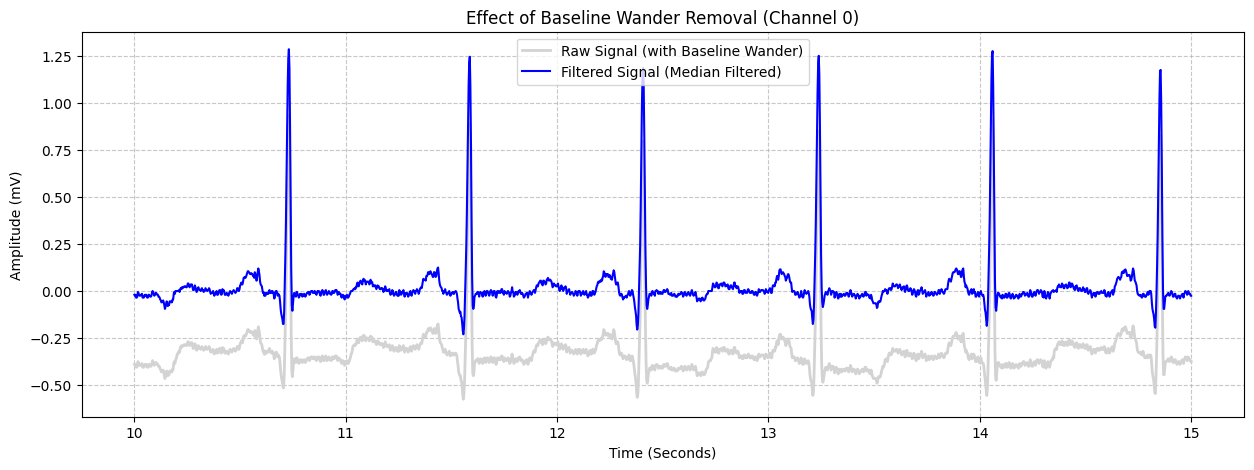

In [10]:
import matplotlib.pyplot as plt

# Define a 5-second segment for visualization
start_sec = 10
duration_sec = 5
start_sample = start_sec * SAMPLING_RATE
end_sample = start_sample + (duration_sec * SAMPLING_RATE)

# Time axis in seconds
time_axis = np.linspace(start_sec, start_sec + duration_sec, end_sample - start_sample)

# 1. Visualize Baseline Wander Removal
plt.figure(figsize=(15, 5))
plt.plot(time_axis, raw_signals[start_sample:end_sample, 0], label='Raw Signal (with Baseline Wander)', color='lightgray', linewidth=2)
plt.plot(time_axis, filtered_signals[start_sample:end_sample, 0], label='Filtered Signal (Median Filtered)', color='blue', linewidth=1.5)
plt.title('Effect of Baseline Wander Removal (Channel 0)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Visualizing Wavelet Denoising
The next visualization demonstrates the effect of the Discrete Wavelet Transform (DWT). Notice how the high-frequency random noise is smoothed out while the sharp amplitude changes of the R-peaks (the chaotic dynamics) are strictly preserved.

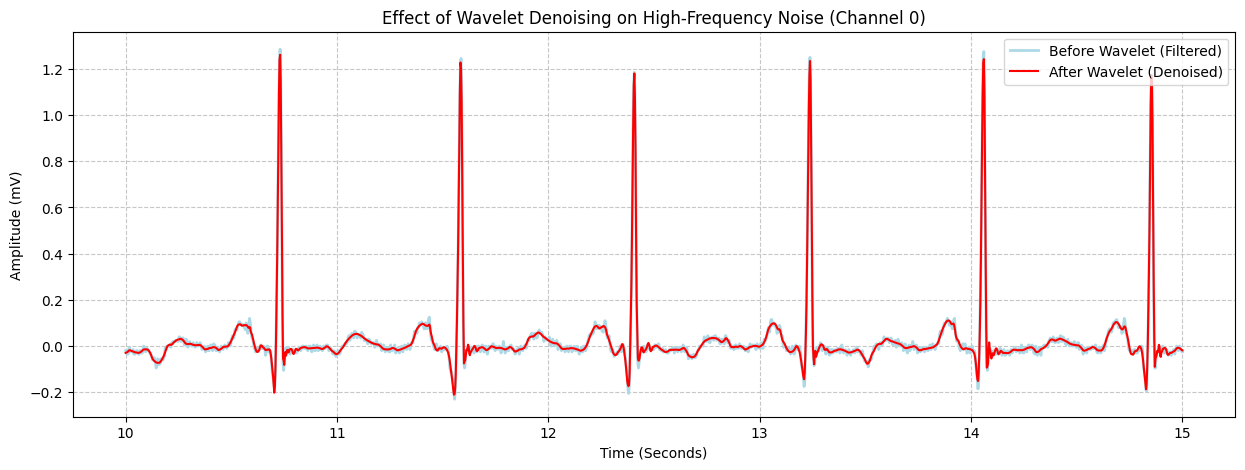

In [11]:
# 2. Visualize Wavelet Denoising
plt.figure(figsize=(15, 5))
plt.plot(time_axis, filtered_signals[start_sample:end_sample, 0], label='Before Wavelet (Filtered)', color='lightblue', linewidth=2)
plt.plot(time_axis, denoised_signals[start_sample:end_sample, 0], label='After Wavelet (Denoised)', color='red', linewidth=1.5)
plt.title('Effect of Wavelet Denoising on High-Frequency Noise (Channel 0)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Visualizing the Forecasting Windows
Finally, we visualize the temporal split created by the window-based slicing method. This illustrates exactly what the model will "see" (the past sequence) and what it will be tasked to "predict" (the future sequence).

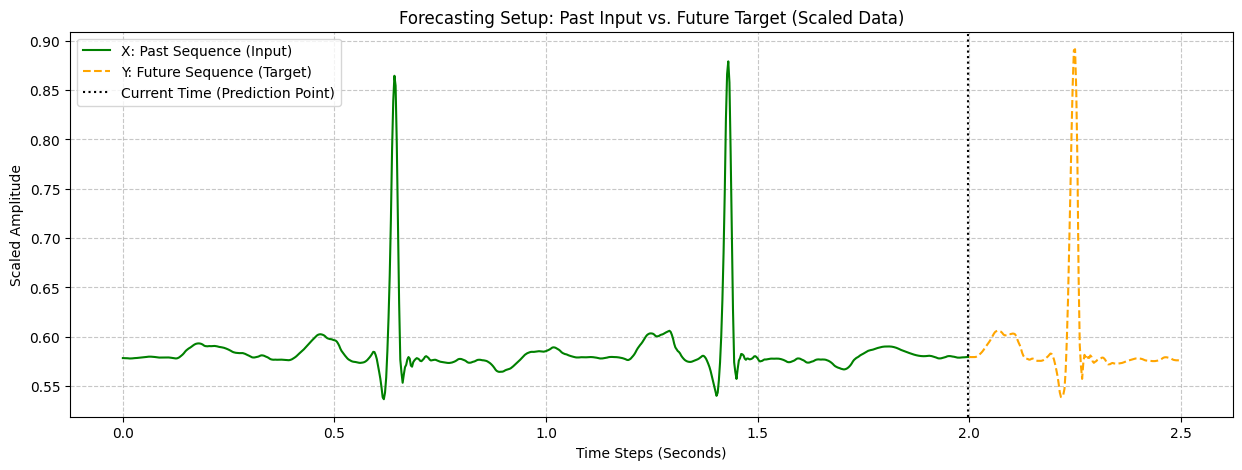

In [12]:
# 3. Visualize a Forecasting Window (X and Y)
# Select a random sample from our training set
sample_index = 100 

X_sample = X_train[sample_index, :, 0] # Channel 0 of X
Y_sample = Y_train[sample_index, :, 0] # Channel 0 of Y

# Create time axes for X and Y based on their lengths
time_X = np.arange(len(X_sample)) / SAMPLING_RATE
time_Y = np.arange(len(X_sample), len(X_sample) + len(Y_sample)) / SAMPLING_RATE

plt.figure(figsize=(15, 5))
plt.plot(time_X, X_sample, label='X: Past Sequence (Input)', color='green')
plt.plot(time_Y, Y_sample, label='Y: Future Sequence (Target)', color='orange', linestyle='--')
plt.axvline(x=time_X[-1], color='black', linestyle=':', label='Current Time (Prediction Point)')
plt.title('Forecasting Setup: Past Input vs. Future Target (Scaled Data)')
plt.xlabel('Time Steps (Seconds)')
plt.ylabel('Scaled Amplitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()